# Pre-trained FCN Backbone Benchmark on PASCAL VOC

Qualitative comparison of the `fcn_resnet50` and `fcn_resnet101` semantic
segmentation models published by `torchvision`, evaluated on a small set of
in-the-wild natural images.

The objective is **not** to reproduce VOC validation numbers (which are well
documented upstream), but to develop intuition for:

- which classes each backbone handles cleanly versus where it fails;
- whether the deeper ResNet-101 backbone produces visibly sharper boundaries;
- how each model behaves on out-of-distribution scenes (cluttered backgrounds,
  multiple instances, partial occlusion).

PASCAL VOC class indices (used by both checkpoints):

```
0=background, 1=aeroplane, 2=bicycle, 3=bird, 4=boat, 5=bottle,
6=bus, 7=car, 8=cat, 9=chair, 10=cow, 11=diningtable, 12=dog,
13=horse, 14=motorbike, 15=person, 16=pottedplant, 17=sheep,
18=sofa, 19=train, 20=tv/monitor
```


In [1]:
import os

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cpu


In [2]:
model_r50 = torch.hub.load("pytorch/vision:v0.10.0", "fcn_resnet50", pretrained=True).to(device).eval()
model_r101 = torch.hub.load("pytorch/vision:v0.10.0", "fcn_resnet101", pretrained=True).to(device).eval()


Using cache found in /Users/paulezennolim/.cache/torch/hub/pytorch_vision_v0.10.0
/Users/paulezennolim/Downloads/Computer-Vision/aca23te_Ezennolim_CV2026/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/paulezennolim/Downloads/Computer-Vision/aca23te_Ezennolim_CV2026/venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=FCN_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Using cache found in /Users/paulezennolim/.cache/torch/hub/pytorch_vision_v0.10.0
/Users/paulezennolim/Downloads/Computer-Vision/aca23te_Ezennoli

In [3]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

VOC_PALETTE = (torch.as_tensor([i for i in range(21)])[:, None]
               * torch.tensor([2 ** 25 - 1, 2 ** 15 - 1, 2 ** 21 - 1]))
VOC_PALETTE = (VOC_PALETTE % 255).numpy().astype("uint8")


def predict(model, pil_image):
    """Run a single image through `model` and return the per-pixel class indices."""
    tensor = preprocess(pil_image.convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)["out"][0]
    return logits.argmax(0).byte().cpu().numpy()


def render_overlay(prediction, target_size):
    """Convert an integer prediction map to a PIL image using the VOC palette."""
    overlay = Image.fromarray(prediction).resize(target_size)
    overlay.putpalette(VOC_PALETTE)
    return overlay


In [4]:
# The default loop expects `dog1.jpg` plus up to five
# additional images named sample_01.jpg ... sample_05.jpg at the project root.
image_paths = [
    "dog1.jpg",
    "sample_01.jpg",
    "sample_02.jpg",
    "sample_03.jpg",
    "sample_04.jpg",
    "sample_05.jpg",
]
image_paths = [p for p in image_paths if os.path.exists(p)]
print(f"Found {len(image_paths)} images: {image_paths}")


Found 6 images: ['dog1.jpg', 'sample_01.jpg', 'sample_02.jpg', 'sample_03.jpg', 'sample_04.jpg', 'sample_05.jpg']


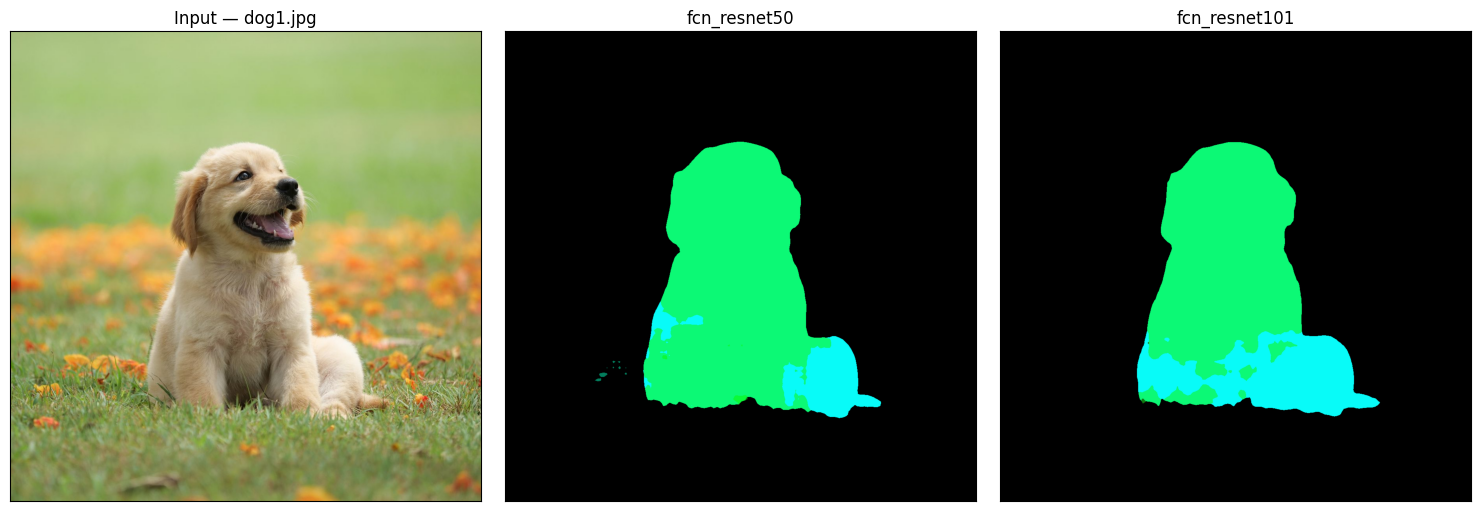

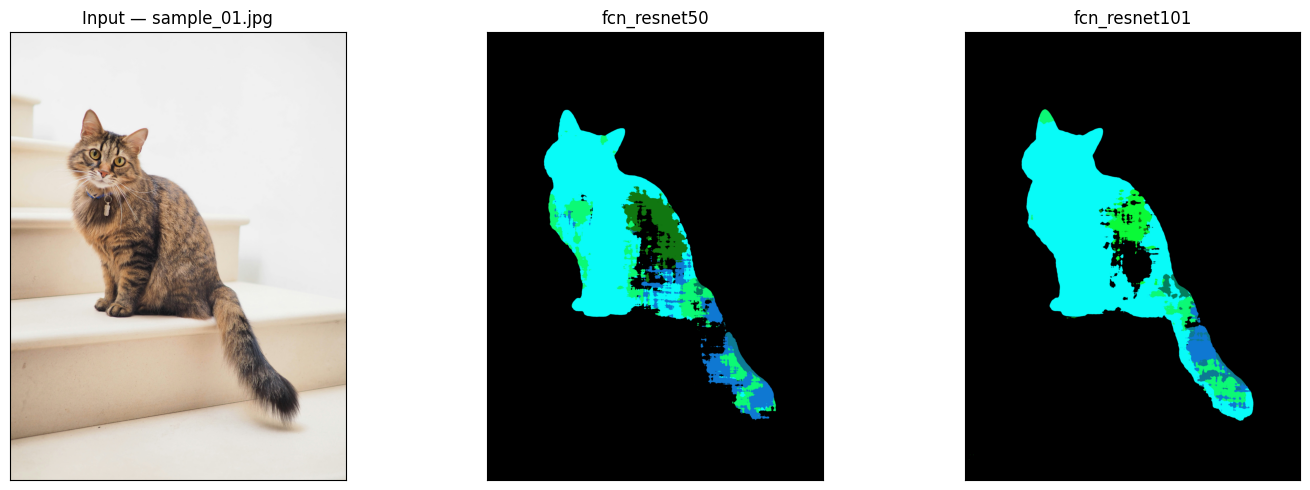

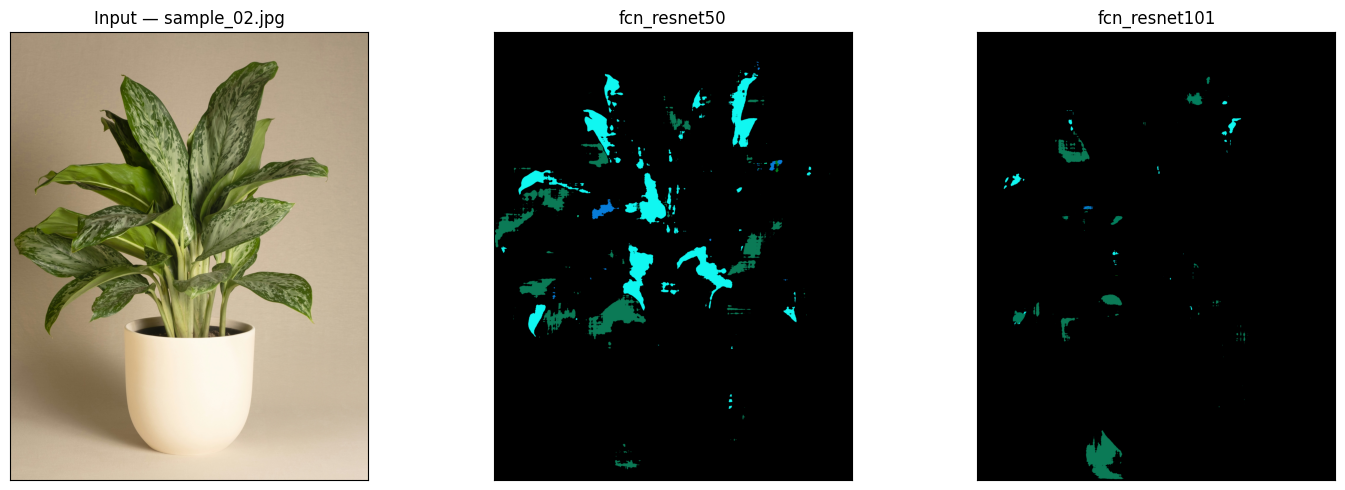

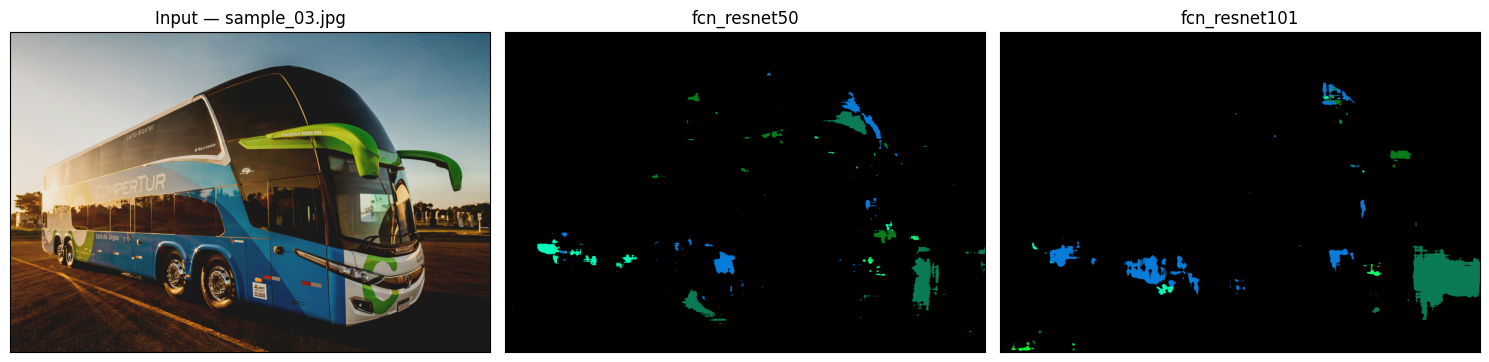

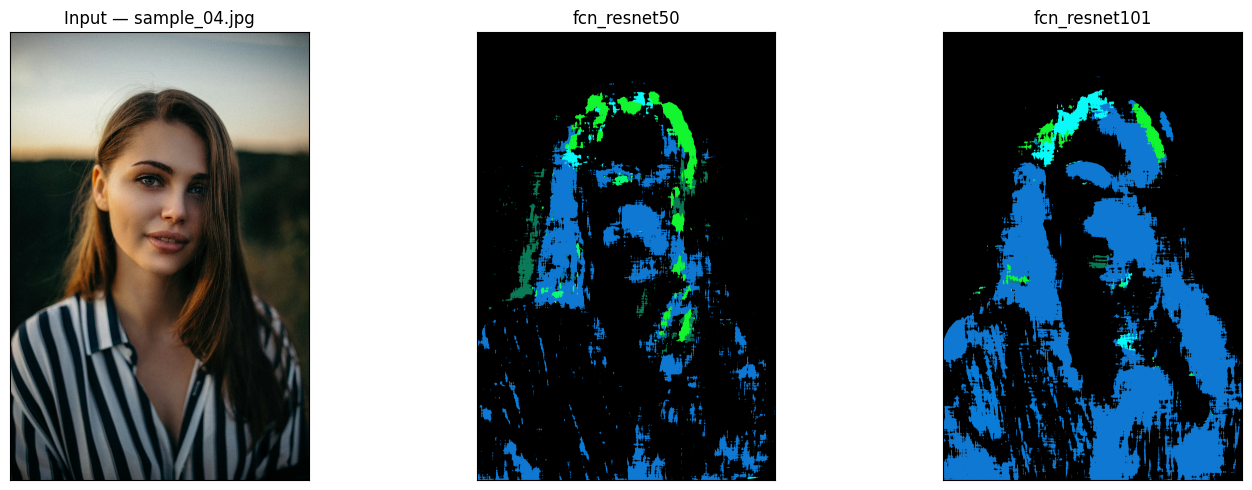

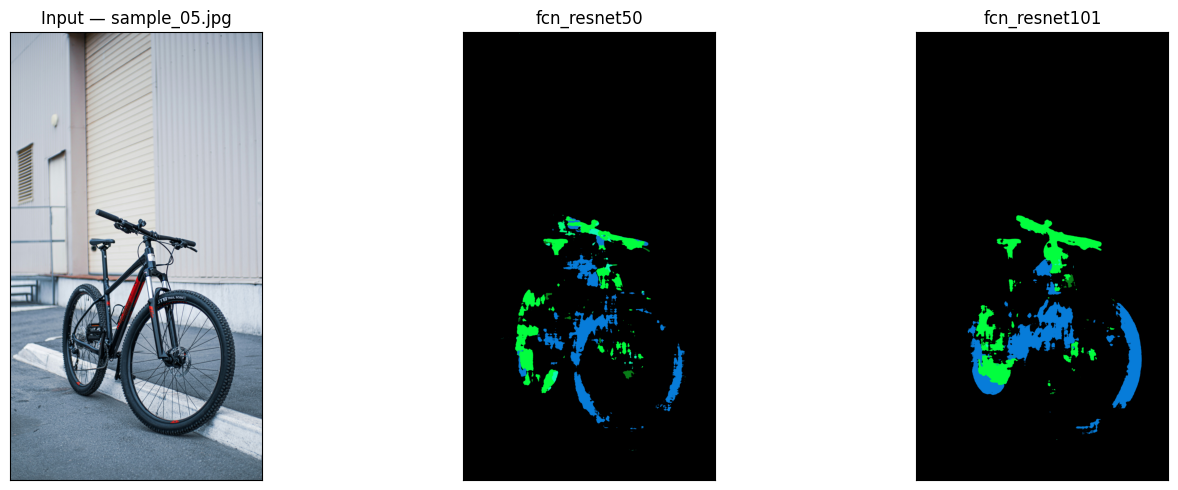

In [5]:
def compare(image_path):
    img = Image.open(image_path).convert("RGB")
    pred_50 = predict(model_r50, img)
    pred_101 = predict(model_r101, img)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(img); ax[0].set_title(f"Input — {os.path.basename(image_path)}")
    ax[1].imshow(render_overlay(pred_50, img.size)); ax[1].set_title("fcn_resnet50")
    ax[2].imshow(render_overlay(pred_101, img.size)); ax[2].set_title("fcn_resnet101")
    for a in ax:
        a.set_xticks([]); a.set_yticks([])
    plt.tight_layout()
    plt.show()


for p in image_paths:
    compare(p)


## Findings

### Qualitative accuracy

- **Dog (`dog1.jpg`) and cat (`sample_01.jpg`) are the cleanest results.** Both backbones recover a coherent object silhouette and largely commit to the right class.
- **Boundaries are tight on the two animal images**, masks hug the subject edges with only minor bleed into the surrounding grass / stairs.
- **Bicycle, person, bus and potted plant are heavily fragmented**, no contiguous mask covers the full object. The model picks up salient patches but fails to produce an object-level segmentation.
- **Multiple instances are not tested here** (each scene contains a single subject), so cross-instance confusion can't be evaluated from this set.

### Failure modes

- **Class confusion between cat and dog.** Both backbones split the puppy between the dog and cat classes, with cat colour appearing on the hindquarters; symmetrically, the cat in `sample_01.jpg` shows small dog patches on the body and tail.
- **Holes and fragmentation on textured / thin-structured objects.** The potted plant predictions are scattered patches across the leaves rather than a coherent plant-or-pot mask, and the bicycle reduces to disjoint blobs around the wheels and frame.
- **Low-contrast lighting destroys the bus prediction.** The back-lit sunset silhouette in `sample_03.jpg` is essentially noise, neither model recovers a recognisable bus shape, despite bus being a well-represented VOC class.
- **Tight portrait crops hurt person segmentation.** `sample_04.jpg` is classified mostly as person (blue) but with dense fragmentation, likely because the head-and-shoulders crop is unlike typical VOC scenes that contain a full standing figure.

### Backbone comparison: ResNet-50 vs ResNet-101

- **Differences are subtle on the easy images.** On the dog and cat both backbones agree on the dominant class and recover similar silhouettes.
- **ResNet-101 is slightly more conservative on hard images.** On the potted plant and bicycle it produces fewer spurious patches than ResNet-50, but the gain is "less wrong", not correct.
- **ResNet-101 is not uniformly better.** On `dog1.jpg` it actually assigns *more* pixels to the cat class than ResNet-50, slightly worsening the dog/cat confusion.
- **Verdict.** For this small natural-image set the extra depth of ResNet-101 does not buy a meaningful qualitative improvement. Both backbones are limited primarily by the PASCAL VOC training distribution (object pose, scale, lighting) rather than by backbone capacity.